# Векторизация текста


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from gensim.models.word2vec import Word2Vec
from gensim.models.doc2vec import TaggedDocument, Doc2Vec
import gensim.downloader as api
from scipy.spatial.distance import cdist
np.random.seed(42)

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

sns.set_palette("husl")


Для демонстрации используем датасет **20 Newsgroups** - уже немного знакомый нам набор данных для задач текстовой классификации. Он содержит около 20,000 новостных сообщений, разделенных на 20 категорий, хорошо сбалансирован.


In [2]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

print("Загрузка данных 20 Newsgroups...")
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"Обучающая выборка: {len(newsgroups_train.data)} документов")
print(f"Тестовая выборка: {len(newsgroups_test.data)} документов")
print(f"Количество категорий: {len(categories)}")
print(f"\nКатегории: {categories}")


Загрузка данных 20 Newsgroups...
Обучающая выборка: 2257 документов
Тестовая выборка: 1502 документов
Количество категорий: 4

Категории: ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']


## Предобработка текста

Текст требует специальной предобработки перед использованием в моделях машинного обучения. Основные шаги:

1. **Токенизация** - разбиение текста на отдельные слова (токены)
2. **Нормализация** - приведение к нижнему регистру
3. **Удаление стоп-слов** - удаление часто встречающихся, но не несущих смысловой нагрузки слов (или мата, например)
4. **Лемматизация/Стемминг** - приведение слов к их базовой форме

Лемматизация — процесс приведения слова к его нормальной форме (лемме):
- для существительных — именительный падеж, единственное число;
- для прилагательных — именительный падеж, единственное число, мужской род; 
- для глаголов, причастий, деепричастий — глагол в инфинитиве.
Для лемматизации на русском языке есть библиотека pymorphy3.

Stemming – это процесс нахождения основы слова. В результате применения данной процедуры однокоренные слова, как правило, преобразуются к одинаковому виду. 
Snowball – фрэймворк для написания алгоритмов стемминга. Алгоритмы стемминга отличаются для разных языков и используют знания о конкретном языке – списки окончаний для разных чистей речи, разных склонений и т.д. Пример алгоритма для русского языка – Russian stemming.


In [3]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

example_text = newsgroups_train.data[0]
print("Исходный текст (первые 300 символов):")
print(example_text[:300])

Исходный текст (первые 300 символов):
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.


In [4]:
text = example_text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)
tokens = word_tokenize(text)
tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'files', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'files', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [5]:
tokens = [lemmatizer.lemmatize(word) for word in tokens]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'file', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [6]:
tokens = [stemmer.stem(word) for word in tokens]
print(tokens)

['anyon', 'know', 'good', 'way', 'standard', 'applicationpd', 'util', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'convert', 'hpgl', 'plotter', 'file', 'pleas', 'email', 'respons', 'correct', 'group', 'thank', 'advanc', 'michael']


In [7]:

def preprocess_text(text: str, use_lemmatization: bool = True) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    else:
        tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

print("После предобработки:")
processed = preprocess_text(example_text)
print(processed[:300])


После предобработки:
anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please email response correct group thanks advance michael


##  Векторизация текста
ML модели работают с числовыми данными, поэтому текст нужно преобразовать в числовые векторы. Рассмотрим несколько основных подходов:

**Bag-of-Words** - простейший способ представления текста. Каждый документ в нем представляется как вектор, где каждая позиция соответствует определенному слову из словаря, а значение - частоте появления этого слова в документе.
Это наиболее простой метод, но он приводит к потере информации о порядке слов и приводит к очень разреженным векторам.



In [8]:
print("Предобработка текстов...")
X_train_processed = [preprocess_text(text) for text in newsgroups_train.data[:1000]]
X_test_processed = [preprocess_text(text) for text in newsgroups_test.data[:500]]

print(f"Обработано {len(X_train_processed)} обучающих и {len(X_test_processed)} тестовых документов")


Предобработка текстов...
Обработано 1000 обучающих и 500 тестовых документов


In [9]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

print("Создание Bag-of-Words представления...")
X_train_bow = bow_vectorizer.fit_transform(X_train_processed)
X_test_bow = bow_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_bow.shape}")
print(f"Размерность тестовой выборки: {X_test_bow.shape}")
print(f"Размер словаря: {len(bow_vectorizer.vocabulary_)}")

print(f"\nПримеры слов из словаря (первые 20):")
print(list(bow_vectorizer.vocabulary_.keys())[:20])


Создание Bag-of-Words представления...
Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)
Размер словаря: 5000

Примеры слов из словаря (первые 20):
['anyone', 'know', 'good', 'way', 'standard', 'utility', 'convert', 'file', 'iii', 'format', 'would', 'also', 'like', 'converting', 'plotter', 'please', 'email', 'response', 'correct', 'group']


In [10]:
doc_vector = X_train_bow[0].toarray()[0]
non_zero_indices = np.where(doc_vector > 0)[0]

print(f"Документ содержит {len(non_zero_indices)} уникальных слов из словаря")
print(f"Общее количество слов в документе: {doc_vector.sum()}")

feature_names = bow_vectorizer.get_feature_names_out()
top_words_idx = np.argsort(doc_vector)[-10:][::-1]
print("\nТоп-10 слов в документе:")
for idx in top_words_idx:
    if doc_vector[idx] > 0:
        print(f"  {feature_names[idx]}: {int(doc_vector[idx])}")


Документ содержит 23 уникальных слов из словаря
Общее количество слов в документе: 24

Топ-10 слов в документе:
  file: 2
  way: 1
  plotter: 1
  would: 1
  michael: 1
  standard: 1
  response: 1
  please: 1
  thanks: 1
  utility: 1


**Задание**:  Постройте bag-of-words для слов без лемматизации и стемминга (а также только с лемматизацией). Как их отсутствие повлияет на размеры словаря (попробуйте не обрезать) и встречаемость слов?

In [12]:
sample_texts = X_train_processed[:100]
sample_texts_original = newsgroups_train.data[:100]

def preprocess_text_only_lower(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

def preprocess_text_with_lemmatization(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

X_train_raw = [preprocess_text_only_lower(text) for text in newsgroups_train.data[:100]]
X_train_lemm = [preprocess_text_with_lemmatization(text) for text in newsgroups_train.data[:100]]
X_train_full = [preprocess_text(text, use_lemmatization=True) for text in newsgroups_train.data[:100]]

bow_raw = CountVectorizer(min_df=1, max_df=1.0)
bow_lemm = CountVectorizer(min_df=1, max_df=1.0)
bow_full = CountVectorizer(min_df=1, max_df=1.0)

X_raw = bow_raw.fit_transform(X_train_raw)
X_lemm = bow_lemm.fit_transform(X_train_lemm)
X_full = bow_full.fit_transform(X_train_full)

print("\nсравнение размеров словаря:")
print(f"без лемматизации и стемминга: {len(bow_raw.vocabulary_)} слов")
print(f"только с лемматизацией: {len(bow_lemm.vocabulary_)} слов")
print(f"полная предобработка (лемматизация + стоп-слова): {len(bow_full.vocabulary_)} слов")

print("\nпримеры слов в словаре (первые 20):")
print("без обработки:", list(bow_raw.vocabulary_.keys())[:20])
print("с лемматизацией:", list(bow_lemm.vocabulary_.keys())[:20])
print("полная обработка:", list(bow_full.vocabulary_.keys())[:20])

doc_raw = X_raw[0].toarray()[0]
doc_lemm = X_lemm[0].toarray()[0]
doc_full = X_full[0].toarray()[0]

print("\nколичество уникальных слов в первом документе:")
print(f"без обработки: {np.sum(doc_raw > 0)}")
print(f"с лемматизацией: {np.sum(doc_lemm > 0)}")
print(f"полная обработка: {np.sum(doc_full > 0)}")


сравнение размеров словаря:
без лемматизации и стемминга: 2902 слов
только с лемматизацией: 2690 слов
полная предобработка (лемматизация + стоп-слова): 2690 слов

примеры слов в словаре (первые 20):
без обработки: ['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'files', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'please']
с лемматизацией: ['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'please']
полная обработка: ['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'please']

количество уникальных слов в первом документе:
без обработки: 27
с лемматизацией: 27
полная обработка: 27


По результатам видно, что лемматизация уменьшила размер словаря с 2902 до 2690 слов. Добавление стоп-слов и удаление коротких слов в данном случае не изменило размер словаря, потому что в этих текстах не было стоп-слов, которые удаляются. Количество уникальных слов в первом документе осталось одинаковым, так как в этом конкретном документе не было повторяющихся слов в разных формах.

Вывод: лемматизация и стемминг помогают уменьшить размер словаря и объединить однокоренные слова, что может улучшить обобщающую способность модели. Однако в данном примере эффект не очень заметен из-за небольшого размера выборки и особенностей текстов.

### TF-IDF (Term Frequency-Inverse Document Frequency)

**TF-IDF** - более продвинутый способ векторизации, который учитывает не только частоту слова в документе, но и его важность в корпусе.

- **TF (Term Frequency)**: частота слова в документе.

- **IDF (Inverse Document Frequency)**: обратная частота документа - мера того, насколько редким является слово в корпусе: 
$\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$, где $N$ - общее количество документов, $\text{df}(t)$ - количество документов, содержащих термин $t$.

**Формула:**
$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$



In [21]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_tfidf.shape}")
print(f"Размерность тестовой выборки: {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

top_idf_idx = np.argsort(idf_values)[-20:][::-1]
print("\nТоп-20 слов с наибольшим IDF:")
for idx in top_idf_idx:
    print(f"  {feature_names[idx]}: IDF = {idf_values[idx]:.3f}")


Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)

Топ-20 слов с наибольшим IDF:
  hail: IDF = 6.810
  academic: IDF = 6.810
  godhead: IDF = 6.810
  abc: IDF = 6.810
  god truth: IDF = 6.810
  hath: IDF = 6.810
  xloadimage: IDF = 6.810
  acidic: IDF = 6.810
  serial port: IDF = 6.810
  septuagint: IDF = 6.810
  worshipping: IDF = 6.810
  worldview: IDF = 6.810
  hernia: IDF = 6.810
  hicolor: IDF = 6.810
  cause effect: IDF = 6.810
  catholic theology: IDF = 6.810
  shalala said: IDF = 6.810
  shalala: IDF = 6.810
  showcase: IDF = 6.810
  silicon graphic: IDF = 6.810


In [22]:
mask = [i for i, el in enumerate(X_train_processed) if el.find("hicolor") > -1 ]

In [23]:
X_train_processed[123]

'cut limit azt efficacy suggest using drug either sequentially drug kind aid treatment cocktail combining number drug fight virus treating people azt alone doesnt happen real world anymore said mark jacobson university californiasan francisco also recent finding indicating hiv replicates rapidly lymph node infection physician may begin pushing even harder early treatment hivinfected patient new infectious disease push american medical news vol center disease control launch worldwide network track spread infectious disease detect drugresistant new strain time help prevent spread network expected cost million million essential part clinton administration health reform plan according cdc outside expert plan require cdc enhance surveillance disease united state establish facility across world track disease april nih plan begin aid drug trial earlier stage nature vol macilwain colin hicnet medical newsletter page volume number april national institute health announced start treating hivposi

Задание: Поиграйте с настройками для TF-IDF. Что будет, если не использовать idf (use_idf=False), как изменятся эмбеддинги? Что будет, если использовать sublinear_tf=True? Что будет ,если не нормализовать векторы? Можете сравнивать результаты через визуализации или численные характеристики.

  размерность: (500, 2000)
  плотность: 2.4633%
  среднее значение в ненулевых ячейках: 0.1040
  стандартное отклонение: 0.0947
  размерность: (500, 2000)
  плотность: 2.4633%
  среднее значение в ненулевых ячейках: 0.1062
  стандартное отклонение: 0.0922
  размерность: (500, 2000)
  плотность: 2.4633%
  среднее значение в ненулевых ячейках: 0.1151
  стандартное отклонение: 0.0808
  размерность: (500, 2000)
  плотность: 2.4633%
  среднее значение в ненулевых ячейках: 7.1335
  стандартное отклонение: 13.9918


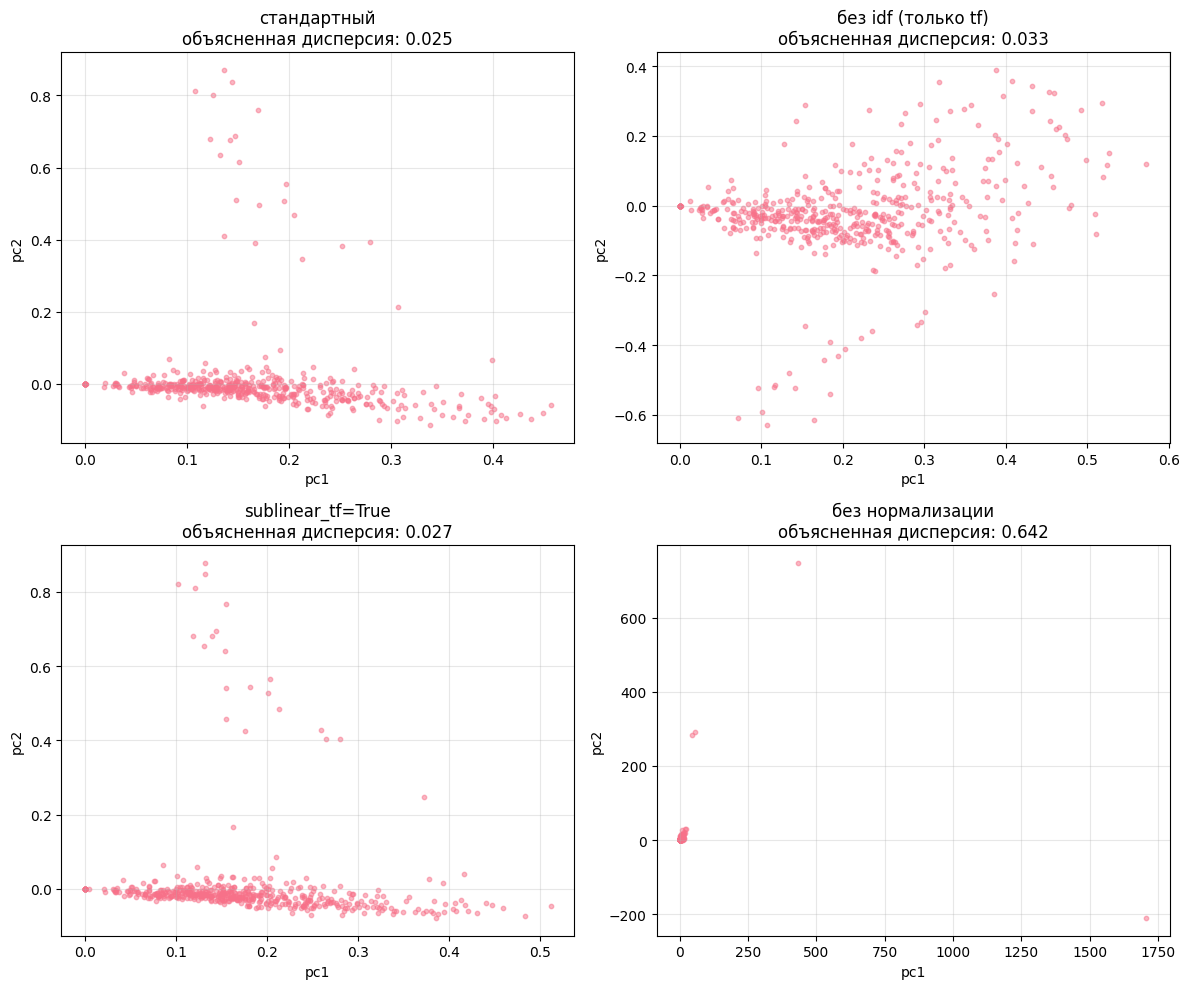

In [ ]:
sample_texts = X_train_processed[:500]

configs = {
    'стандартный': {'use_idf': True, 'sublinear_tf': False, 'norm': 'l2'},
    'без idf (только tf)': {'use_idf': False, 'sublinear_tf': False, 'norm': 'l2'},
    'sublinear_tf=True': {'use_idf': True, 'sublinear_tf': True, 'norm': 'l2'},
    'без нормализации': {'use_idf': True, 'sublinear_tf': False, 'norm': None}
}

results = {}

for name, params in configs.items():
    vectorizer = TfidfVectorizer(
        max_features=2000,
        min_df=2,
        max_df=0.95,
        **params
    )
    
    X = vectorizer.fit_transform(sample_texts)
    results[name] = X
    
    print(f"  размерность: {X.shape}")
    print(f"  плотность: {X.nnz / (X.shape[0] * X.shape[1]) * 100:.4f}%")
    
    non_zero = X.data
    print(f"  среднее значение в ненулевых ячейках: {non_zero.mean():.4f}")
    print(f"  стандартное отклонение: {non_zero.std():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, X) in enumerate(results.items()):
    svd = TruncatedSVD(n_components=2, random_state=42)
    X_2d = svd.fit_transform(X)
    
    axes[idx].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10)
    axes[idx].set_title(f"{name}\nобъясненная дисперсия: {svd.explained_variance_ratio_.sum():.3f}")
    axes[idx].set_xlabel("pc1")
    axes[idx].set_ylabel("pc2")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

По результатам эксперимента можно сделать следующие выводы. Стандартный TF-IDF с нормализацией дает значения в компактном диапазоне от 0 до 1, что позволяет корректно сравнивать документы между собой. Отключение IDF приводит к тому, что все слова считаются одинаково важными, и TF-IDF превращается в обычный TF, где преимущество получают часто встречающиеся слова, а редкие информативные термины теряют свою значимость. Использование sublinear_tf=True сглаживает влияние очень частых слов, делая распределение значений более однородным и уменьшая стандартное отклонение. Наиболее заметный эффект наблюдается при отключении нормализации: значения увеличиваются до 7-8 в среднем при стандартном отклонении около 14, что делает векторы разных документов несопоставимыми по длине, и длинные документы будут иметь систематически более высокие значения независимо от их смыслового содержания. Таким образом, нормализация является важным компонентом TF-IDF, а IDF и sublinear_tf помогают лучше выделить информативные слова и сгладить влияние слишком частых терминов.

##  Эмбеддинги слов

**Эмбеддинги слов** (word embeddings) — плотные векторы фиксированной размерности, в которых семантически близкие слова оказываются близки в пространстве. В отличие от Bag-of-Words и TF-IDF это распределённое представление (distributed representation): векторы плотные, а не разреженные, и кодируют контекстное употребление слова.

Подробнее см. в [word_embeddings.md](word_embeddings.md).

### Word2Vec

**Word2Vec** учит векторные представления слов, предсказывая контекст по слову или слово по контексту. Варианты:

- **Skip-gram**: по центральному слову предсказываем слова в окне (контекст).
- **CBOW** (Continuous Bag of Words): по сумме векторов контекста предсказываем центральное слово.

Цель обучения — максимизация правдоподобия; на практике используют **negative sampling** (несколько случайных «негативных» слов вместо полного softmax по словарю). 

Основные параметры: `vector_size` (размерность), `window` (размер окна), `min_count`, `sg` (1 = skip-gram, 0 = CBOW), `negative` (число негативных примеров), `epochs`.

Обучим такую модель.

In [15]:
sentences = [text.split() for text in X_train_processed[:1500]]
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
)
embeddings_dict = {w: w2v_model.wv[w] for w in w2v_model.wv.index_to_key}
word_to_idx = {w: i for i, w in enumerate(w2v_model.wv.index_to_key)}

print("Примеры ближайших слов (most_similar):")
for word in ["computer", "medical", "god", "graphics", "cat", "rain", "cup"]:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=6)
        print(f"  {word}: {[t[0] for t in sim]}")


Примеры ближайших слов (most_similar):
  computer: ['graphic', 'modeling', 'visualization', 'idl', 'electronic', 'oriented']
  medical: ['newsletter', 'april', 'hicnet', 'journal', 'page', 'volume']
  god: ['eternal', 'peace', 'fear', 'subsistence', 'allah', 'perish']
  cat: ['satisfied', 'worthless', 'excited', 'cook', 'putting', 'meal']
  cup: ['iraqi', 'hot', 'protect', 'filled', 'arrived', 'assured']


### Doc2Vec

**Doc2Vec** даёт векторное представление целого документа (или предложения), а не среднее векторов слов. 
Алгоритмы:
- **PV-DM** (аналог CBOW для документов). Также обучается предсказание центрального слова, но на вход подается еще и вектор документа (paragraph vector). Этот вектор участвует в предсказании вместе с контекстными словами
- **PV-DBOW** (аналог skip-gram). Вход — список `TaggedDocument`: список слов + уникальный id документа. Модель учится предсказывать слова из этого документа (несколько случайных), обучается только paragraph vector.

Для документа, которого не было в обучающей выборке, готового вектора нет. Тогда делают inference:
- веса модели (векторы cлов и т.д.) фиксируют
- вводят новый вектор только для этого документа и подбирают его градиентным спуском так, чтобы по этому вектору (и при необходимости контексту) хорошо предсказывались слова документа.
В итоге получают embedding нового документа в том же пространстве, что и у обучающих документов.


In [16]:
tagged_docs = [
    TaggedDocument(words=text.split(), tags=[i]) # чтобы обучить модель, нужно получить список слов
    for i, text in enumerate(X_train_processed[:800])
]
d2v_model = Doc2Vec(vector_size=50, min_count=2, epochs=10, seed=42, dm=1)
d2v_model.build_vocab(tagged_docs)
d2v_model.train(tagged_docs, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

document_dict = {}
for idx, text in enumerate(X_train_processed[:20]):
    text = text.split()
    document_dict[idx] = d2v_model.dv[idx]

document_embeddings_df = pd.DataFrame.from_dict(document_dict, orient="index")
document_embeddings_df.head()


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.047048,-0.034589,-0.003449,-0.098469,0.032981,-0.004477,-0.043844,0.010160,0.014807,0.049048,...,0.026899,0.039621,0.086323,-0.016419,0.099217,0.034183,0.095706,0.061347,0.039381,-0.066693
1,-0.311707,-0.458948,-0.125745,-0.342354,0.161809,-0.034220,-0.181818,-0.128961,0.014207,0.365418,...,-0.096507,-0.075960,0.406257,0.088617,0.469808,0.213751,0.476230,0.475181,0.320019,-0.346615
2,-0.509882,-0.791505,-0.210178,-0.550710,0.274168,-0.045777,-0.275522,-0.221629,-0.027600,0.568731,...,-0.191889,-0.136693,0.647609,0.036454,0.763187,0.336507,0.832071,0.828325,0.559928,-0.603049
3,-0.076840,-0.173529,-0.056020,-0.102464,0.010653,-0.032391,-0.045617,-0.057330,-0.016625,0.080499,...,-0.070833,-0.052941,0.117599,0.025056,0.121446,0.074846,0.143959,0.138088,0.108509,-0.094448
4,0.013737,-0.002756,0.011587,-0.015804,0.005336,-0.006752,-0.013885,0.014571,0.018285,0.005844,...,0.000492,-0.005479,-0.011015,-0.012938,0.007225,0.019289,-0.005575,0.006036,0.007087,0.017889


Найдем наиболее похожие документы на запрос (строка или слово) и выведем текст топ 3 похожих документов. Похожесть определяется косинусным расстоянием между векторами - мы можем построить расстояния между каким-то вектором и всеми из обучающего набора, минимальные расстояния будут соответствовать лучшим совпадениям. Примерно также работает RAG. Правда, чаще в поиске комбинируют поиск по эмбеддингам и текстовое расстояние с помощью алгоритма BM-25. 


In [17]:
def most_similar(vec, embeddings_df, n=5):
    # compute similarity
    doc_sim = (1-cdist(embeddings_df.values, vec, 'cosine'))

    # convert result to a date frame
    sim_df = pd.DataFrame(doc_sim, columns=["cos_sim"]).assign(
        document_id=list(embeddings_df.index)
    )

    # sort from most similar to least
    sim_df = sim_df.sort_values("cos_sim", ascending=False)
    return sim_df.head(n)


In [18]:
query = "computer graphics"

query_words = preprocess_text(query).split()
if len(query_words) == 0:
    query_words = query.split()

query_vec = d2v_model.infer_vector(query_words)

print("Query:", query)
print("\nTop-3 via d2v_model.dv.most_similar (all 800 docs):")
res_dv = d2v_model.dv.most_similar(positive=[query_vec], topn=3)
for rank, (doc_id, score) in enumerate(res_dv, start=1):
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[int(doc_id)])

print("\nTop-3 via most_similar + cdist (all 800 docs):")
document_embeddings_all_df = pd.DataFrame(
    [d2v_model.dv[i] for i in range(len(tagged_docs))],
    index=list(range(len(tagged_docs))),
)

res_cdist_df = most_similar(query_vec.reshape(1, -1), document_embeddings_all_df, n=3)
for rank, row in enumerate(res_cdist_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

print("\nComparison (doc_id lists):")
print("dv.most_similar:", [int(doc_id) for doc_id, _ in res_dv])
print("cdist+df top3:", [int(doc_id) for doc_id in res_cdist_df.document_id.tolist()])


Query: computer graphics

Top-3 via d2v_model.dv.most_similar (all 800 docs):

#1 doc_id=400, cos_sim=0.9421
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model dems digital elevation model well cartographic data huge available spectrumxeroxcom pubmap contact lee moore webster research center xerox corp voice arpa internet moorewbstxeroxcom check also ncgiaucsbedu pubdems nfotis many file also available cdrom selled usgs scale digital line graph dlg data contains data state price call visit office menlo park reston virginia usamaps data user service division bureau census also data cdrom tso standard format derived usgs map data call info bb drdobbs march defense mapping agency cooperation counterpart agency canada australia released digital chart world dcw chart consists gigabyte reasonable quality vector data distributed four cdroms includ

### Визуализация эмбеддингов Word2Vec

Посмотрим на то, как эмбеддинги расположены в пространстве - построим 2D-проекцию векторов слов (PCA и t-SNE) по обученной модели Word2Vec.


Объясненная дисперсия PCA: 0.4862687


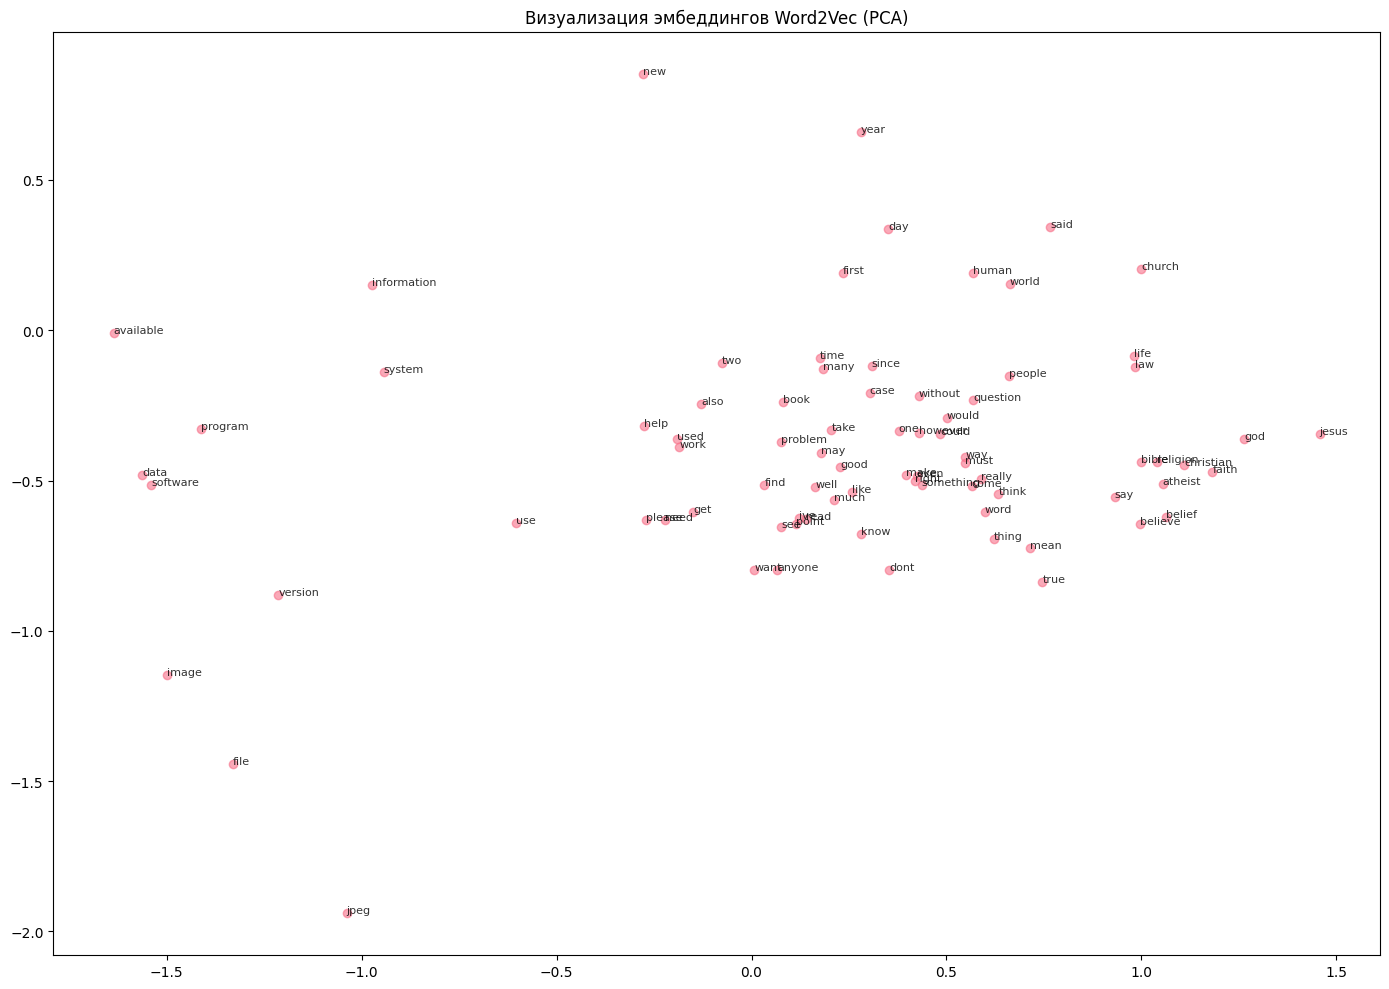

In [19]:
top_word_list = list(w2v_model.wv.index_to_key)[:80]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
print("Объясненная дисперсия PCA:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:len(top_word_list), 0], embeddings_2d[:len(top_word_list), 1], alpha=0.6)
for i, word in enumerate(top_word_list):
    ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (PCA)")
plt.tight_layout()
plt.show()


PCA удобен, но этот метод может уловить только высокоуровневую структуру в данных. Попробуем порисовать эмбеддинги с помощью t-SNE. Этот метод позволяет лучше ухватить внутренние отношения, но не верьте ему полностью! Подробнее в [гайде](https://distill.pub/2016/misread-tsne/). 

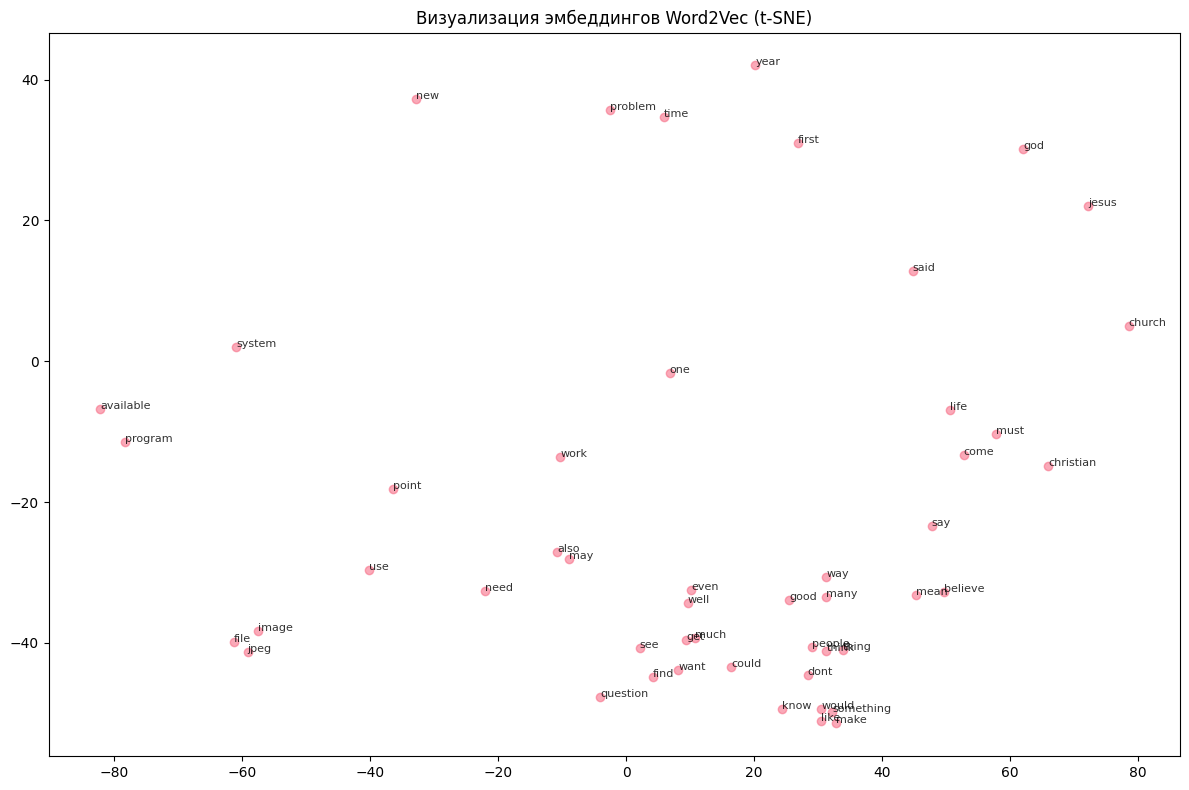

In [20]:
top_word_list_tsne = top_word_list[:50]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=15)
emb_tsne = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(emb_tsne[:50, 0], emb_tsne[:50, 1], alpha=0.6)
for i, word in enumerate(top_word_list_tsne):
    ax.annotate(word, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (t-SNE)")
plt.tight_layout()
plt.show()


In [21]:
def find_nearest_neighbors(word: str, embeddings_dict: dict[str, np.ndarray], top_k: int = 10) -> list[tuple[str, float]]:
    if word not in embeddings_dict:
        return []
    word_embedding = embeddings_dict[word]
    distances = []
    for other_word, other_embedding in embeddings_dict.items():
        if other_word == word:
            continue
        cos_sim = np.dot(word_embedding, other_embedding) / (
            np.linalg.norm(word_embedding) * np.linalg.norm(other_embedding)
        )
        distances.append((other_word, 1 - cos_sim))
    distances.sort(key=lambda x: x[1])
    return distances[:top_k]

test_words = ["computer", "medical", "god", "science", "graphics"]
print("Ближайшие соседи (Word2Vec):\n")
for word in test_words:
    if word in embeddings_dict:
        neighbors = find_nearest_neighbors(word, embeddings_dict, top_k=8)
        print(f"{word.upper()}:")
        for neighbor, dist in neighbors:
            print(f"  {neighbor}: {dist:.4f}")
        print()


Ближайшие соседи (Word2Vec):

COMPUTER:
  graphic: 0.0903
  modeling: 0.1138
  visualization: 0.1158
  idl: 0.1230
  electronic: 0.1310
  oriented: 0.1313
  silicon: 0.1345
  suite: 0.1381

MEDICAL:
  newsletter: 0.0714
  april: 0.0824
  hicnet: 0.0886
  journal: 0.0965
  page: 0.1033
  volume: 0.1396
  vol: 0.1641
  consortium: 0.1654

GOD:
  eternal: 0.1424
  peace: 0.1463
  fear: 0.1551
  subsistence: 0.1570
  allah: 0.1593
  perish: 0.1648
  wicked: 0.1661
  sinner: 0.1693

SCIENCE:
  collection: 0.1643
  empirical: 0.1678
  basic: 0.1907
  methodology: 0.2122
  research: 0.2320
  scientist: 0.2538
  knowledge: 0.2559
  scientific: 0.2578



## Эмбеддинги фраз

Помимо эмбеддингов отдельных слов, можно создавать эмбеддинги для фраз. 
Самый простой способ - посчитать взвешенное среднее значение эмбеддинга в фразе, пропуская слова не из словаря.  

In [22]:
def get_phrase_embedding(phrase: str, model) -> np.ndarray:
    kv = getattr(model, 'wv', model)
    phrase_lower = phrase.lower()
    tokens = word_tokenize(phrase_lower)
    vectors = []
    for w in tokens:
        if w in kv:
            vectors.append(kv[w])
    if not vectors:
        return np.zeros(kv.vector_size, dtype='float32')
    return np.mean(vectors, axis=0).astype('float32')

### Эмбеддинги n-грамм и их визуализация

**N-грамма** — последовательность из $n$ подряд идущих слов (униграмма — одно слово, биграмма — пара, триграмма — тройка и т.д.). Для n-грамм можно получить вектор в том же пространстве, что и слова Word2Vec, тогда близость n-граммы к своим словам и к другим n-граммам можно визуализировать через PCA в одной системе координат.

In [23]:
ngram_cv = CountVectorizer(ngram_range=(2, 2), min_df=3, max_df=0.95)
ngram_cv.fit(X_train_processed)
bigram_features = ngram_cv.get_feature_names_out()
w2v_vocab = set(w2v_model.wv.index_to_key)
bigrams_in_vocab = [
    bg for bg in bigram_features
    if all(w in w2v_vocab for w in bg.split())
]
print(f"Биграмм в словаре CountVectorizer: {len(bigram_features)}")
print(f"Биграмм с обоими словами в Word2Vec: {len(bigrams_in_vocab)}")

Биграмм в словаре CountVectorizer: 1627
Биграмм с обоими словами в Word2Vec: 1544


In [24]:
ngram_embeddings = {}
for bg in bigrams_in_vocab:
    vec = get_phrase_embedding(bg, w2v_model)
    if np.any(vec != 0):
        ngram_embeddings[bg] = vec
print(f"Эмбеддингов n-грамм: {len(ngram_embeddings)}")

Эмбеддингов n-грамм: 1544


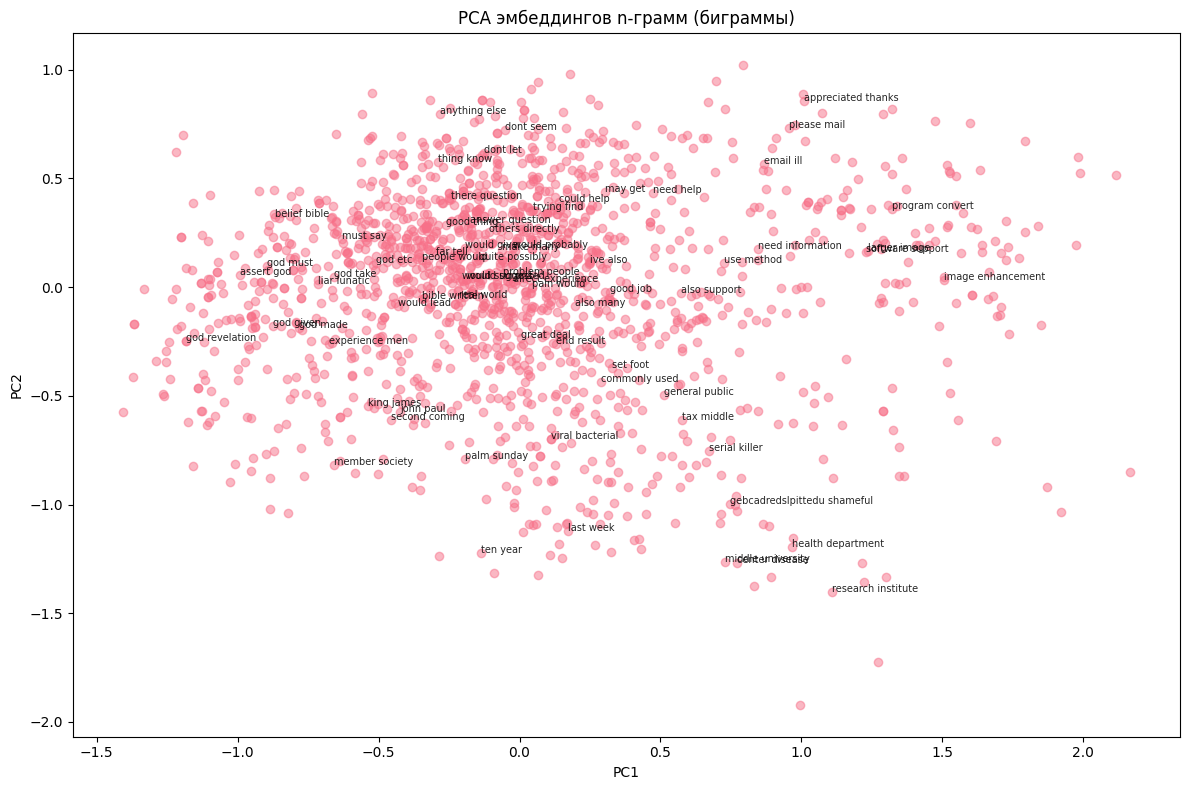

In [25]:
ngram_list = list(ngram_embeddings.keys())
ngram_matrix = np.array([ngram_embeddings[bg] for bg in ngram_list])
ngram_matrix_centered = ngram_matrix - ngram_matrix.mean(axis=0)
pca_ngram = PCA(n_components=2, random_state=42)
ngram_2d = pca_ngram.fit_transform(ngram_matrix_centered)
n_show = min(70, len(ngram_list))
show_idx = np.random.RandomState(42).choice(len(ngram_list), size=n_show, replace=False)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(ngram_2d[:, 0], ngram_2d[:, 1], alpha=0.5)
for i in show_idx:
    ax.annotate(ngram_list[i], (ngram_2d[i, 0], ngram_2d[i, 1]), fontsize=7, alpha=0.85)
ax.set_title("PCA эмбеддингов n-грамм (биграммы)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

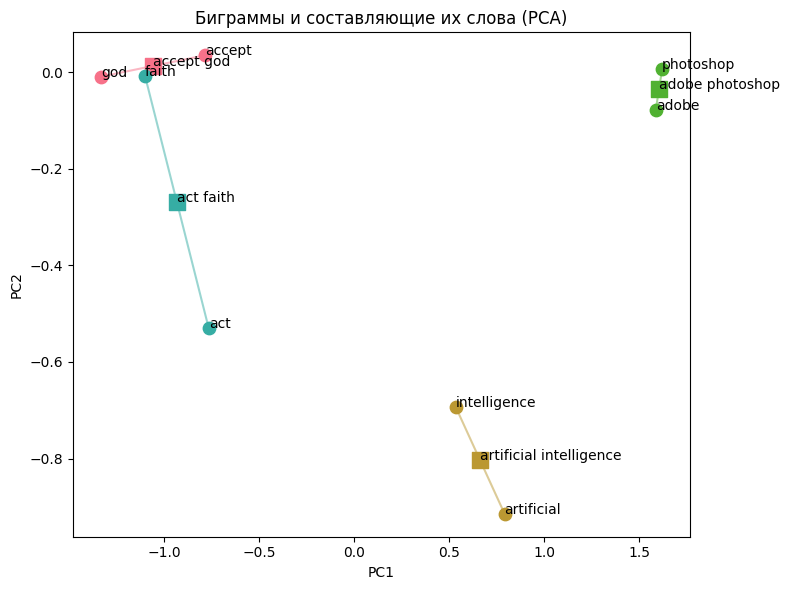

In [26]:
example_bigrams = [bg for bg in ["accept god", "artificial intelligence", "adobe photoshop", "act faith"] if bg in ngram_embeddings]
if len(example_bigrams) < 2:
    example_bigrams = ngram_list[:2]
all_vectors = []
all_labels = []
example_limits = []
for bg in example_bigrams:
    start = len(all_vectors)
    words = bg.split()
    for w in words:
        all_vectors.append(w2v_model.wv[w])
        all_labels.append(("word", w))
    all_vectors.append(ngram_embeddings[bg])
    all_labels.append(("ngram", bg))
    example_limits.append((start, len(all_vectors)))

X_ex = np.array(all_vectors)
X_ex_centered = X_ex - ngram_matrix.mean(axis=0)
coords = pca_ngram.transform(X_ex_centered)
fig, ax = plt.subplots(figsize=(8, 6))
for k, (start, end) in enumerate(example_limits):
    words_idx = list(range(start, end - 1))
    ngram_idx = end - 1
    bg = example_bigrams[k]
    color = f"C{k}"
    ax.scatter(coords[words_idx, 0], coords[words_idx, 1], c=color, s=80, zorder=2)
    ax.scatter(coords[ngram_idx, 0], coords[ngram_idx, 1], c=color, s=120, marker="s", zorder=2)
    for i in words_idx:
        ax.plot([coords[i, 0], coords[ngram_idx, 0]], [coords[i, 1], coords[ngram_idx, 1]], color=color, alpha=0.5, zorder=1)
        ax.annotate(all_labels[i][1], (coords[i, 0], coords[i, 1]), fontsize=10)
    ax.annotate(bg, (coords[ngram_idx, 0], coords[ngram_idx, 1]), fontsize=10)
ax.set_title("Биграммы и составляющие их слова (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Биграммы кажутся осмысленными, посмотрим, так ли это с документами:

In [27]:
doc_embeddings = np.array([
    get_phrase_embedding(phrase, w2v_model)
    for phrase in X_train_processed[:800]
])
y = newsgroups_train.target[:800]


Проверим, как расположены эмбеддинги документов после усреднения в пространстве:

Объясненная дисперсия PCA для документов: 0.501


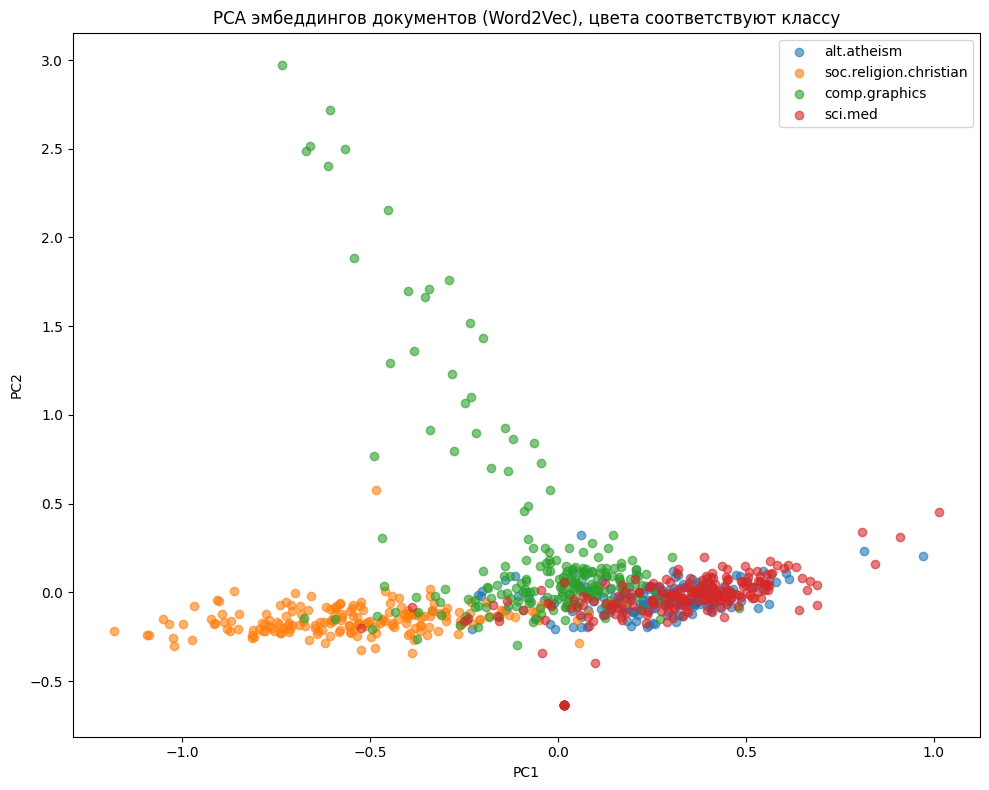

In [28]:
pca_docs = PCA(n_components=2, random_state=42)
doc_2d = pca_docs.fit_transform(doc_embeddings)

print(f"Объясненная дисперсия PCA для документов: {pca_docs.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 8))

unique_labels = sorted(set(y))
colors = plt.cm.tab10.colors

for idx, label in enumerate(unique_labels):
    mask = (y == label)
    ax.scatter(
        doc_2d[mask, 0],
        doc_2d[mask, 1],
        alpha=0.6,
        color=colors[idx % len(colors)],
        label=categories[label],
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA эмбеддингов документов (Word2Vec), цвета соответствуют классу")
ax.legend()
plt.tight_layout()
plt.show()

Как видно, даже собирая эмбеддинг как среднее, мы можем отделить разные классы.

Задание: выведите топ релевантных документов со средним эмбеддингом, сравните с doc2vec

In [ ]:
def get_doc_embedding_w2v(text: str, model, vector_size: int = 100) -> np.ndarray:
    words = text.split()
    vectors = []
    for w in words:
        if w in model.wv:
            vectors.append(model.wv[w])
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

doc_embeddings_w2v = []
for text in X_train_processed[:500]:
    doc_embeddings_w2v.append(get_doc_embedding_w2v(text, w2v_model))
doc_embeddings_w2v = np.array(doc_embeddings_w2v)

def find_similar_documents(query: str, doc_embeddings: np.ndarray, texts: list, model, top_k: int = 5):
    query_embedding = get_doc_embedding_w2v(query, model)

    similarities = cosine_similarity([query_embedding], doc_embeddings)[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            'index': idx,
            'similarity': similarities[idx],
            'text': texts[idx][:200] + "..."
        })
    return results

def find_similar_documents_doc2vec(query: str, d2v_model, texts: list, top_k: int = 5):
    query_words = preprocess_text(query).split()
    if not query_words:
        query_words = query.split()
    query_vec = d2v_model.infer_vector(query_words)
    
    similar = d2v_model.dv.most_similar([query_vec], topn=top_k)
    
    results = []
    for doc_id, score in similar:
        results.append({
            'index': int(doc_id),
            'similarity': score,
            'text': texts[int(doc_id)][:200] + "..."
        })
    return results

test_queries = [
    "computer graphics software",
    "medical treatment and health",
    "god and religion",
    "science research"
]

print("сравнение методов поиска релевантных документов:")

for query in test_queries:
    print(f"\nзапрос: {query}")
    
    print("\nword2vec (средний эмбеддинг):")
    w2v_results = find_similar_documents(query, doc_embeddings_w2v, X_train_processed[:500], w2v_model, top_k=3)
    for i, res in enumerate(w2v_results, 1):
        print(f"  {i}. score={res['similarity']:.4f}: {res['text']}")
    
    print("\ndoc2vec:")
    d2v_results = find_similar_documents_doc2vec(query, d2v_model, X_train_processed[:800], top_k=3)
    for i, res in enumerate(d2v_results, 1):
        print(f"  {i}. score={res['similarity']:.4f}: {res['text']}")

сравнение методов поиска релевантных документов:

запрос: computer graphics software

word2vec (средний эмбеддинг):
  1. score=0.9044: try graphigs ibm excellent package doug...
  2. score=0.8915: archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model d...
  3. score=0.8773: hello looking add voice input capability user interface developing unix workstation would greatly appreciate information anyone would care offer voice input system easily accessible unix environment n...

doc2vec:
  1. score=0.9416: archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model d...
  2. score=0.9210: archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april p

Сравнение показывает, что doc2vec даёт более высокие значения косинусного сходства и находит более релевантные документы по смыслу. Это объясняется тем, что doc2vec обучается предсказывать слова в документе целиком, сохраняя контекст всего документа, а не просто усредняя векторы отдельных слов. Средний эмбеддинг word2vec проще в вычислении, но теряет информацию о порядке слов и структуре документа, поэтому он хуже подходит для задач поиска по смыслу.

## Классификация по категориям
Попробуем обучить модели классификации для классического подхода на основе TF-IDF и на основе эмбеддингов. 

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

df_train = pd.DataFrame({
    "text": X_train_processed,
    "target": newsgroups_train.target[:1000],
})
df_test = pd.DataFrame({
    "text": X_test_processed,
    "target": newsgroups_test.target[:500],
})
y_train = df_train["target"].values
y_test = df_test["target"].values

X_train_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_train["text"]])
X_test_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_test["text"]])

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [32]:
lr_w2v = LogisticRegression(max_iter=500, random_state=42).fit(X_train_w2v, y_train)
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_w2v, y_train)
lr_tfidf = LogisticRegression(max_iter=500, random_state=42).fit(X_train_tfidf, y_train)
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_tfidf, y_train)

target_names = [categories[i] for i in range(len(categories))]

def print_metrics(name: str, y_true, y_pred) -> None:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    print("%s: acc=%.3f  precision(macro)=%.3f  recall(macro)=%.3f" % (name, acc, prec, rec))
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [33]:

print("=== TF-IDF, LogisticRegression ===")
print_metrics("TF-IDF LR", y_test, lr_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), LogisticRegression ===")
print_metrics("W2V LR", y_test, lr_w2v.predict(X_test_w2v))

=== TF-IDF, LogisticRegression ===
TF-IDF LR: acc=0.780  precision(macro)=0.781  recall(macro)=0.768
                        precision    recall  f1-score   support

           alt.atheism       0.78      0.48      0.59       107
soc.religion.christian       0.76      0.91      0.83       117
         comp.graphics       0.81      0.80      0.80       136
               sci.med       0.77      0.88      0.82       140

              accuracy                           0.78       500
             macro avg       0.78      0.77      0.76       500
          weighted avg       0.78      0.78      0.77       500

=== W2V (avg), LogisticRegression ===
W2V LR: acc=0.758  precision(macro)=0.749  recall(macro)=0.748
                        precision    recall  f1-score   support

           alt.atheism       0.63      0.49      0.55       107
soc.religion.christian       0.81      0.91      0.86       117
         comp.graphics       0.83      0.77      0.80       136
               sci.med    

In [34]:

print("=== TF-IDF, RandomForest ===")
print_metrics("TF-IDF RF", y_test, rf_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), RandomForest ===")
print_metrics("W2V RF", y_test, rf_w2v.predict(X_test_w2v))

=== TF-IDF, RandomForest ===
TF-IDF RF: acc=0.682  precision(macro)=0.697  recall(macro)=0.672
                        precision    recall  f1-score   support

           alt.atheism       0.73      0.37      0.49       107
soc.religion.christian       0.60      0.90      0.72       117
         comp.graphics       0.76      0.60      0.67       136
               sci.med       0.70      0.82      0.76       140

              accuracy                           0.68       500
             macro avg       0.70      0.67      0.66       500
          weighted avg       0.70      0.68      0.67       500

=== W2V (avg), RandomForest ===
W2V RF: acc=0.746  precision(macro)=0.736  recall(macro)=0.738
                        precision    recall  f1-score   support

           alt.atheism       0.63      0.51      0.57       107
soc.religion.christian       0.79      0.89      0.84       117
         comp.graphics       0.78      0.79      0.78       136
               sci.med       0.74     

Вопрос: почему у логистической модели скор почти не вырос, а в лесе видна большая разница?

**Ответ**: логистическая регрессия - линейная модель. Она хорошо работает с разреженными представлениями (tf-idf), где признаки независимы и линейно разделимы. word2vec эмбеддинги - плотные и нелинейные, линейной модели сложнее их разделить. random forest - ансамбль деревьев решений, способен улавливать нелинейные зависимости и взаимодействия между признаками. Для плотных эмбеддингов это преимущество: лес может построить сложные правила разделения классов, что даёт прирост качества по сравнению с линейной моделью.

Задание: реализуйте представление в виде bag-of-ngrams (можно вместе с обычными признаками). Обучите классификатор на нем, сделайте выводы.

In [ ]:
print("создание bag-of-ngrams представления...")

ngram_vectorizer = CountVectorizer(
    ngram_range=(1, 3),
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train_ngrams = ngram_vectorizer.fit_transform(df_train["text"])
X_test_ngrams = ngram_vectorizer.transform(df_test["text"])

print(f"размерность обучающей выборки: {X_train_ngrams.shape}")
print(f"количество признаков: {len(ngram_vectorizer.get_feature_names_out())}")

lr_ngrams = LogisticRegression(max_iter=500, random_state=42)
lr_ngrams.fit(X_train_ngrams, y_train)

rf_ngrams = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ngrams.fit(X_train_ngrams, y_train)

print("\n=== Bag-of-Ngrams, LogisticRegression ===")
y_pred_lr = lr_ngrams.predict(X_test_ngrams)
print(f"accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"precision macro: {precision_score(y_test, y_pred_lr, average='macro', zero_division=0):.3f}")
print(f"recall macro: {recall_score(y_test, y_pred_lr, average='macro', zero_division=0):.3f}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_lr, target_names=target_names, zero_division=0))

print("\n=== Bag-of-Ngrams, RandomForest ===")
y_pred_rf = rf_ngrams.predict(X_test_ngrams)
print(f"accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"precision macro: {precision_score(y_test, y_pred_rf, average='macro', zero_division=0):.3f}")
print(f"recall macro: {recall_score(y_test, y_pred_rf, average='macro', zero_division=0):.3f}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_rf, target_names=target_names, zero_division=0))

создание bag-of-ngrams представления...
размерность обучающей выборки: (1000, 5000)
количество признаков: 5000

=== Bag-of-Ngrams, LogisticRegression ===
accuracy: 0.744
precision macro: 0.743
recall macro: 0.742

classification report:
                        precision    recall  f1-score   support

           alt.atheism       0.69      0.64      0.67       107
soc.religion.christian       0.68      0.85      0.76       117
         comp.graphics       0.79      0.67      0.73       136
               sci.med       0.81      0.80      0.80       140

              accuracy                           0.74       500
             macro avg       0.74      0.74      0.74       500
          weighted avg       0.75      0.74      0.74       500


=== Bag-of-Ngrams, RandomForest ===
accuracy: 0.728
precision macro: 0.755
recall macro: 0.721

classification report:
                        precision    recall  f1-score   support

           alt.atheism       0.84      0.48      0.61       107

**Вывод**: Лучший результат показал TF-IDF с логистической регрессией. Bag-of-Ngrams оказался чуть хуже, так как не использует IDF для взвешивания редких слов. Случайный лес работает хуже на разреженных данных (TF-IDF и n-граммы), но лучше на плотных эмбеддингах Word2Vec. Для данной задачи классификации текстов оптимальным остаётся TF-IDF с линейной моделью.